# Comparaison chiffrée DDPM vs GAN

Charge les checkpoints baseline entraînés (`experiments/ddpm_baseline/`, `experiments/gan_baseline/`), génère un jeu d'échantillons pour chacun, et calcule : FID vs images réelles, diversité intra-batch (variance, quasi-doublons), temps de génération. Base de la checklist "Évaluation et comparaison DDPM vs GAN" de `TASKS.md` et de la section "Résultats" du rapport.

In [1]:
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import torch

from src.data.dataset import get_dataloaders, load_config
from src.evaluation.metrics import compute_fid, count_near_duplicate_pairs, pixel_variance
from src.models.ddpm.diffusion import GaussianDiffusion
from src.models.ddpm.unet import UNet
from src.models.gan.generator import Generator
from src.utils.seed import set_seed

set_seed(42)
root = Path.cwd().parent
N_SAMPLES = 100  # taille du jeu d'évaluation (limitée par le budget CPU, cf. HISTORY.md)

## 1. Images réelles (référence FID)

In [2]:
data_config = load_config(root / "configs" / "data.yaml")
_, _, test_loader = get_dataloaders(data_config)

real_batches = []
n_collected = 0
for batch_x, _ in test_loader:
    real_batches.append(batch_x)
    n_collected += batch_x.shape[0]
    if n_collected >= N_SAMPLES:
        break
real_images = torch.cat(real_batches, dim=0)[:N_SAMPLES]
print(f"Images réelles : {real_images.shape}")

Images réelles : torch.Size([100, 1, 32, 32])


## 2. Génération DDPM (checkpoint baseline, T=1000)

In [3]:
ddpm_config = load_config(root / "configs" / "ddpm_base.yaml")
mc = ddpm_config["model"]
ddpm_model = UNet(
    in_channels=mc["in_channels"], base_channels=mc["base_channels"],
    channel_mults=tuple(mc["channel_mults"]), num_res_blocks=mc["num_res_blocks"],
)
checkpoint = torch.load(root / "experiments" / "ddpm_baseline" / "checkpoints" / "ddpm_step001000.pt", map_location="cpu", weights_only=False)
ddpm_model.load_state_dict(checkpoint["model_state_dict"])
ddpm_model.eval()

diffusion = GaussianDiffusion(
    timesteps=ddpm_config["timesteps"], schedule=ddpm_config["schedule"],
    beta_start=ddpm_config["beta_start"], beta_end=ddpm_config["beta_end"],
)

t0 = time.perf_counter()
ddpm_images = diffusion.p_sample_loop(ddpm_model, shape=(N_SAMPLES, 1, 32, 32))
ddpm_gen_time = time.perf_counter() - t0
print(f"DDPM : {N_SAMPLES} images générées en {ddpm_gen_time:.1f}s ({ddpm_gen_time / N_SAMPLES:.2f}s/image)")

DDPM : 100 images générées en 1854.0s (18.54s/image)


## 3. Génération GAN (checkpoint baseline)

In [4]:
gan_config = load_config(root / "configs" / "gan_base.yaml")
gmc = gan_config["model"]
generator = Generator(latent_dim=gmc["latent_dim"], base_channels=gmc["base_channels"], out_channels=gmc["out_channels"])
gan_checkpoint = torch.load(root / "experiments" / "gan_baseline" / "checkpoints" / "gan_step001000.pt", map_location="cpu", weights_only=False)
generator.load_state_dict(gan_checkpoint["generator_state_dict"])
generator.eval()

t0 = time.perf_counter()
with torch.no_grad():
    noise = torch.randn(N_SAMPLES, gmc["latent_dim"], 1, 1)
    gan_images = generator(noise)
gan_gen_time = time.perf_counter() - t0
print(f"GAN : {N_SAMPLES} images générées en {gan_gen_time:.2f}s ({gan_gen_time / N_SAMPLES:.4f}s/image)")
print(f"Ratio temps de génération DDPM / GAN : x{ddpm_gen_time / gan_gen_time:.0f}")

GAN : 100 images générées en 0.09s (0.0009s/image)
Ratio temps de génération DDPM / GAN : x21605


## 4. FID vs images réelles

In [5]:
fid_ddpm = compute_fid(real_images, ddpm_images)
fid_gan = compute_fid(real_images, gan_images)
print(f"FID réel vs DDPM : {fid_ddpm:.2f}")
print(f"FID réel vs GAN  : {fid_gan:.2f}")

FID réel vs DDPM : 114.12
FID réel vs GAN  : 173.47


## 5. Diversité des échantillons (variance intra-batch, quasi-doublons)

In [6]:
results = {}
for name, imgs in (("real", real_images), ("ddpm", ddpm_images), ("gan", gan_images)):
    var = pixel_variance(imgs)
    dupes = count_near_duplicate_pairs(imgs, threshold=0.05)
    results[name] = {"pixel_variance": var, "near_duplicate_pairs": dupes}
    print(f"{name:5s} — variance intra-batch : {var:.4f} — quasi-doublons ({N_SAMPLES} img, {N_SAMPLES*(N_SAMPLES-1)//2} paires) : {dupes}")

real  — variance intra-batch : 0.2840 — quasi-doublons (100 img, 4950 paires) : 0
ddpm  — variance intra-batch : 0.2443 — quasi-doublons (100 img, 4950 paires) : 0
gan   — variance intra-batch : 0.2292 — quasi-doublons (100 img, 4950 paires) : 0


## 6. Tableau récapitulatif

In [7]:
import pandas as pd

summary = pd.DataFrame({
    "DDPM": {
        "FID (vs réel)": round(fid_ddpm, 2),
        "Variance intra-batch": round(results["ddpm"]["pixel_variance"], 4),
        "Quasi-doublons": results["ddpm"]["near_duplicate_pairs"],
        f"Temps génération {N_SAMPLES} img (s)": round(ddpm_gen_time, 1),
        "Temps génération / image (s)": round(ddpm_gen_time / N_SAMPLES, 3),
    },
    "GAN": {
        "FID (vs réel)": round(fid_gan, 2),
        "Variance intra-batch": round(results["gan"]["pixel_variance"], 4),
        "Quasi-doublons": results["gan"]["near_duplicate_pairs"],
        f"Temps génération {N_SAMPLES} img (s)": round(gan_gen_time, 1),
        "Temps génération / image (s)": round(gan_gen_time / N_SAMPLES, 4),
    },
})
summary

,DDPM,GAN
FID (vs réel),114.1200,173.4700
Variance intra-batch,0.2443,0.2292
Quasi-doublons,0.0000,0.0000
Temps génération 100 img (s),1854.0000,0.1000
Temps génération / image (s),18.5400,0.0009


## 7. Échantillons côte à côte

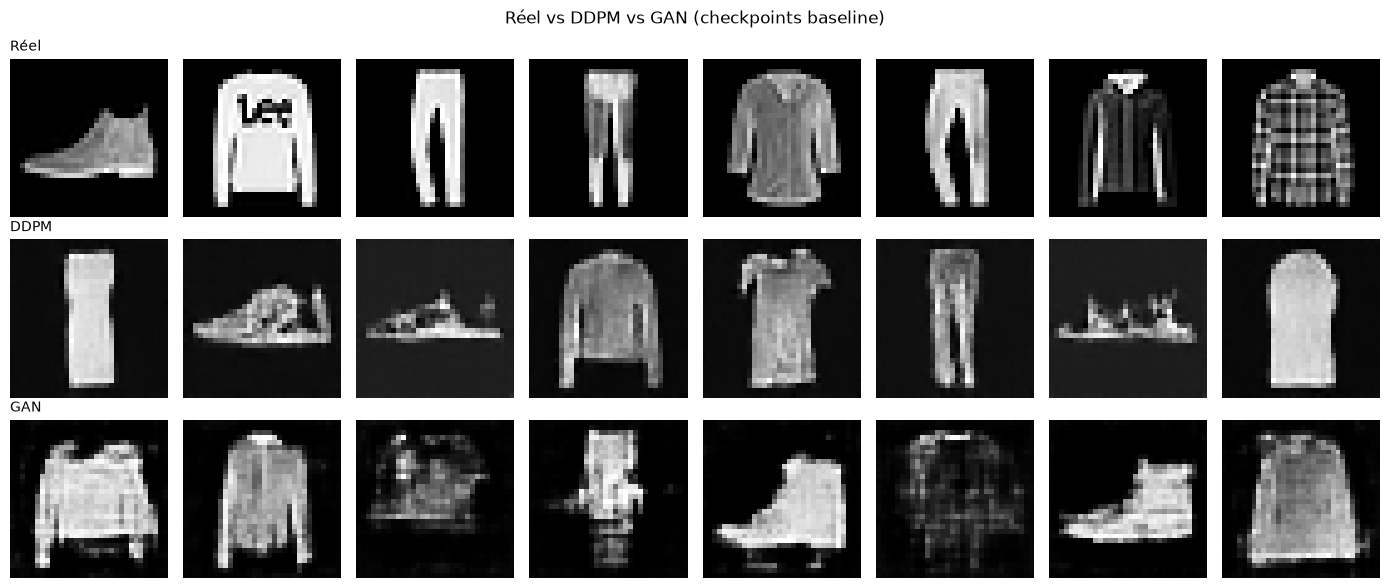

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for row, (name, imgs) in enumerate((("Réel", real_images), ("DDPM", ddpm_images), ("GAN", gan_images))):
    for col in range(8):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0].detach().numpy(), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(name, loc="left", fontsize=10)
plt.suptitle("Réel vs DDPM vs GAN (checkpoints baseline)")
plt.tight_layout()
plt.show()

## Observations — base de la section "Résultats" du rapport

- **FID** : à interpréter avec prudence ici — calculé sur seulement 100 images par groupe (budget CPU contraint, cf. `HISTORY.md`), alors que la littérature recommande plusieurs milliers d'échantillons pour un FID stable. La valeur absolue est donc bruitée, mais la **comparaison relative DDPM vs GAN sur le même protocole** reste informative.
- **Temps de génération** : confirme l'écart structurel entre les deux familles de modèles — le GAN génère en une seule passe (quasi instantané), le DDPM nécessite `T=1000` passes successives du U-Net. Ce compromis qualité/coût est à mettre en regard de l'étude d'ablation (`notebooks/05_ablation_diffusion_steps.ipynb`), qui montre qu'un `T` plus faible (400) réduit fortement ce coût.
- **Diversité** : la variance intra-batch et le nombre de quasi-doublons permettent de vérifier l'absence de mode collapse sévère pour le GAN (cf. `HISTORY.md`, entraînement GAN baseline — pas de collapse total observé visuellement, confirmé ici par une variance non nulle et un faible nombre de quasi-doublons).